# 11 数据分析

> **图 11.1**：式 (11.2) 中模型的三个变量的效应（左侧）及其总索博尔指数（右侧）

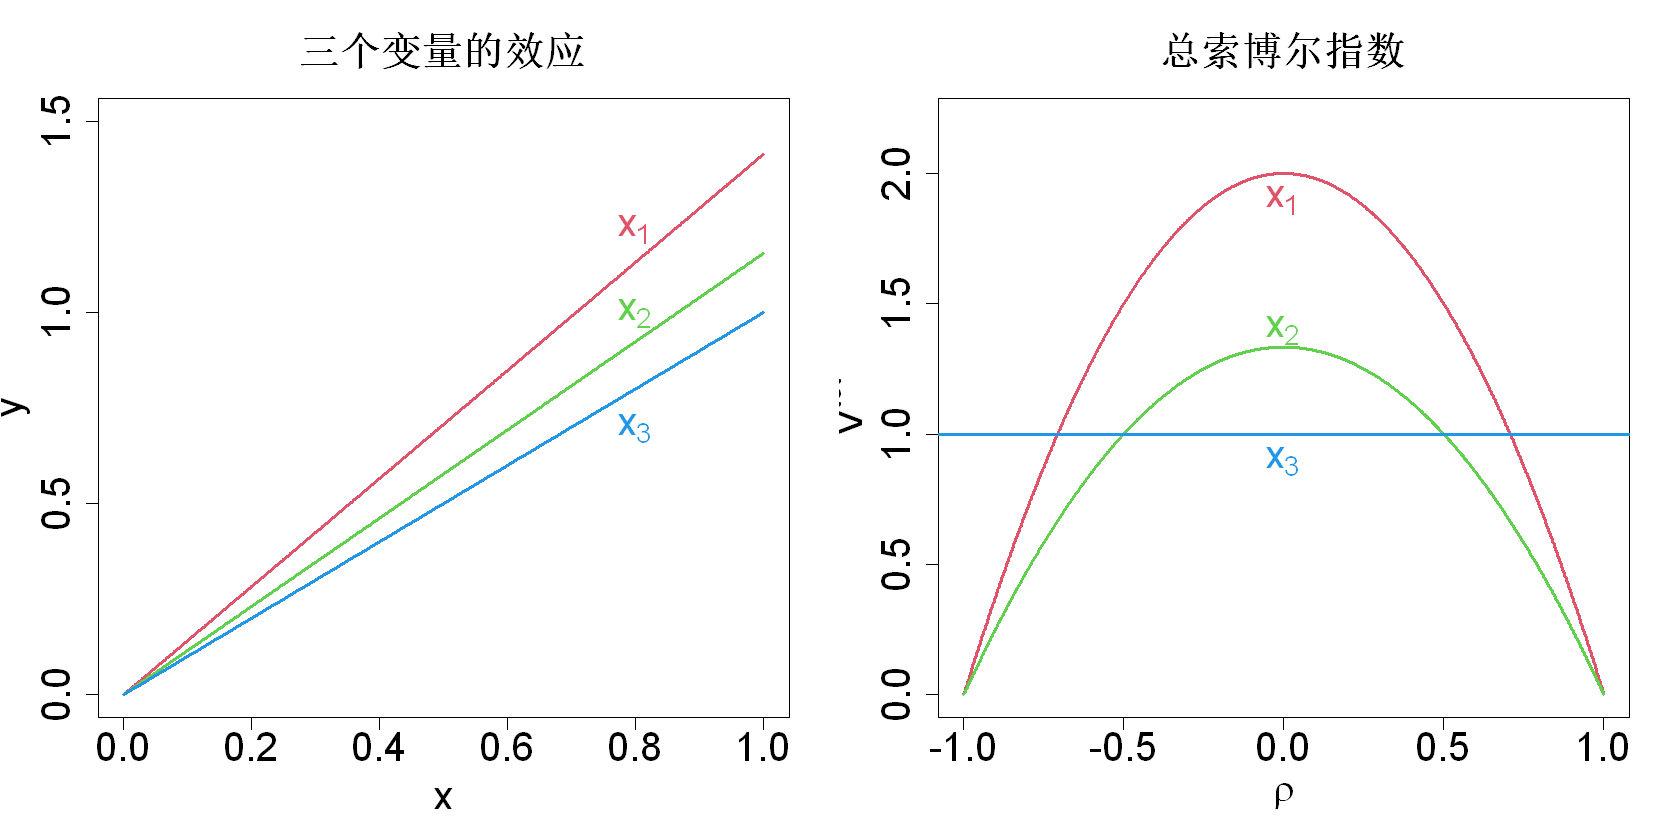

In [24]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/11.1-plot.RData")){
  library(MASS)
  set.seed(123)
  x_vals=seq(0,1,length=1000)
  x_vals2=seq(-1,1,length=1000)
  curve1_y=sqrt(2)*x_vals
  curve2_y=2/sqrt(3)*x_vals
  curve3_y=1*x_vals
  curve4_y=2*(1-x_vals2^2)
  curve5_y=4/3*(1-x_vals2^2)
  save(x_vals,x_vals2,curve1_y,curve2_y,curve3_y,curve4_y,curve5_y,file="data/11.1-plot.RData")
}

load("data/11.1-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(x_vals,curve1_y,type="l",lwd=3,col=2,main="三个变量的效应",cex.main=2,xlab="x",ylab="y",cex.lab=2,cex.axis=2,xlim=c(0,1),ylim=c(0,1.5))
lines(x_vals,curve2_y,col=3,lwd=3)
lines(x_vals,curve3_y,col=4,lwd=3)
text(0.8,1.22,expression(x[1]),cex=2,col=2)
text(0.8,1.0,expression(x[2]),cex=2,col=3)
text(0.8,0.7,expression(x[3]),cex=2,col=4)
plot(x_vals2,curve4_y,type="l",lwd=3,col=2,main="总索博尔指数",cex.main=2,xlab=expression(rho),ylab=expression(V^tot),cex.lab=2,cex.axis=2,xlim=c(-1,1),ylim=c(0,2.2))
lines(x_vals2,curve5_y,col=3,lwd=3)
abline(h=1,col=4,lwd=3)
text(0,1.9,expression(x[1]),cex=2,col=2)
text(0,1.4,expression(x[2]),cex=2,col=3)
text(0,0.9,expression(x[3]),cex=2,col=4)

> **图 11.2**：采用全部八个预测变量，以及通过基于总指标的因子重要性排序与选择方法筛选得到的因子集，分别使用随机森林（左侧）与高斯过程（右侧），在混凝土数据集测试集上得到的均方根预测误差

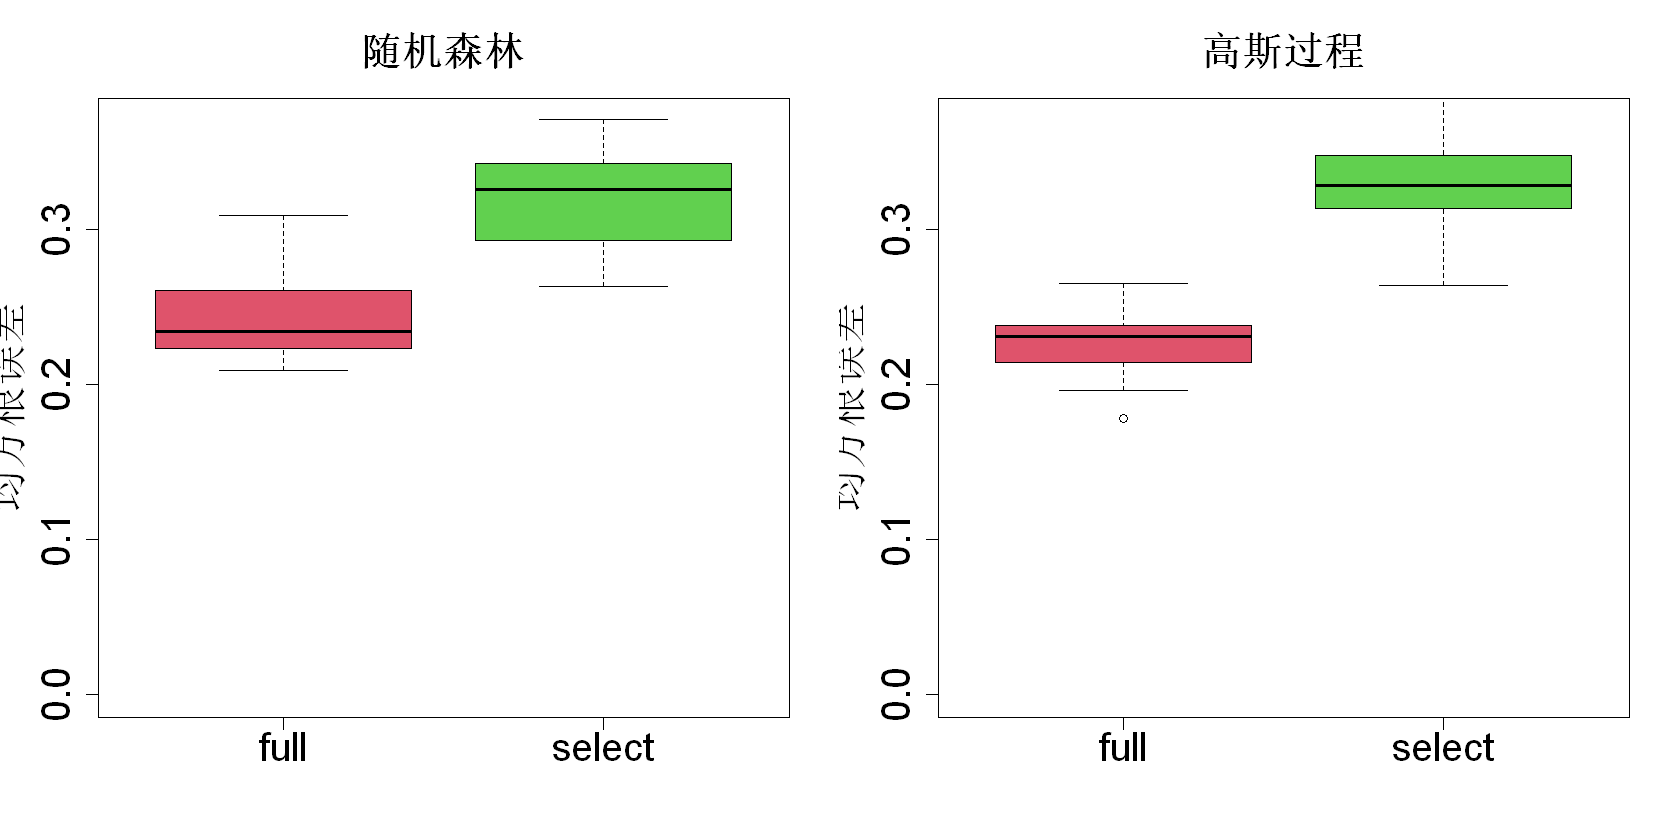

In [25]:
library(SPlit)
library(randomForest)
library(rkriging)
library(first)
set.seed(123)

if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/11.2-plot.RData")){
  concrete=read.csv(file="data/Concrete_Data.csv",fileEncoding="UTF-8-BOM")
  concrete.scale=data.frame(scale(concrete))
  rmse.RF=matrix(0,nrow=30,ncol=2)
  rmse.GP=matrix(0,nrow=30,ncol=2)
  for (i in 1:30) {
    ind=SPlit(concrete,splitRatio=0.1)
    train=concrete.scale[-ind,]
    test=concrete.scale[ind,]
    a=randomForest(x=train[,1:8],y=train[,9])
    pred=predict(a,test[,1:8])
    rmse.RF[i,1]=sqrt(mean((test$y-pred)^2))
    a=Fit.Kriging(X=train[,1:8],y=train[,9],interpolation=FALSE,kernel.parameters=list(type="Gaussian"))
    pred=Predict.Kriging(a,test[,1:8])$mean
    rmse.GP[i,1]=sqrt(mean((test$y-pred)^2))
    sel=first(X=train[,-9],y=train[,9])
    sel=(sel > 0)  # 逻辑向量，标记哪些因子被选中
    a=randomForest(x=train[,-9][,sel],y=train[,9])
    pred=predict(a,test[,-9][,sel])
    rmse.RF[i,2]=sqrt(mean((test$y-pred)^2))
    a=Fit.Kriging(X=train[,-9][,sel],y=train[,9],interpolation=FALSE,kernel.parameters=list(type="Gaussian"))
    pred=Predict.Kriging(a,test[,-9][,sel])$mean
    rmse.GP[i,2]=sqrt(mean((test$y-pred)^2))
  }
  save(rmse.RF,rmse.GP,file="data/11.2-plot.RData") 
}

load("data/11.2-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
boxplot(data.frame(full=rmse.RF[,1],select=rmse.RF[,2]),ylim=c(0,0.37),main="随机森林",ylab="均方根误差",cex.main=2,cex.lab=2,cex.axis=2,col=c(2,3))
boxplot(data.frame(full=rmse.GP[,1],select=rmse.GP[,2]),ylim=c(0,0.37),main="高斯过程",ylab="均方根误差",cex.main=2,cex.lab=2,cex.axis=2,col=c(2,3))

> **图 11.3**：对于风电数据集，孪生高斯过程的预测结果以实线展示

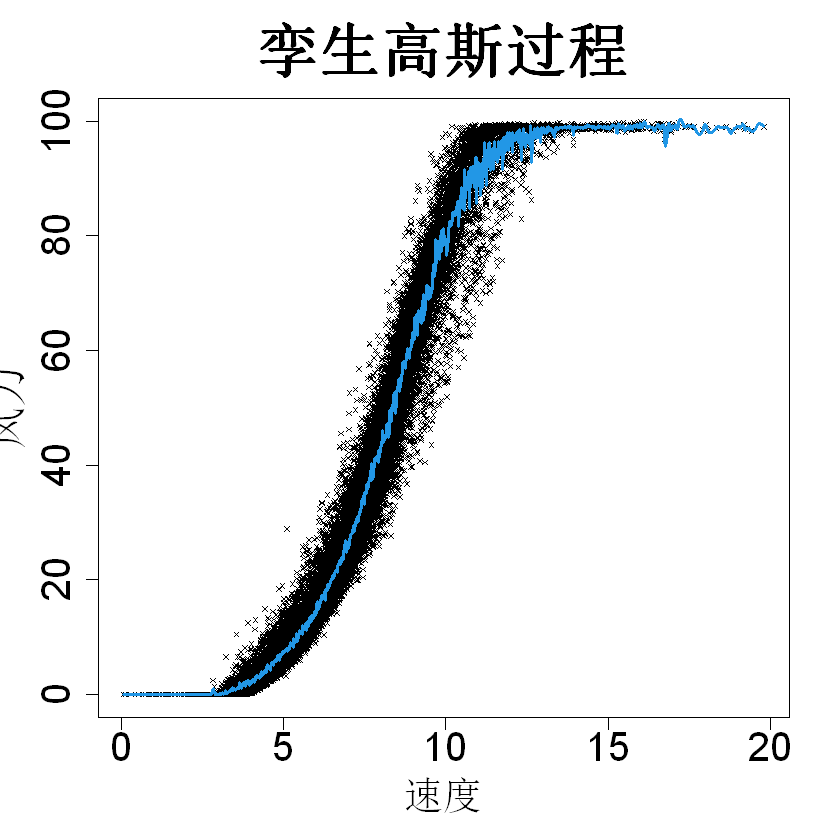

In [26]:
library(twingp)
if (!file.exists("data/11.3-plot.RData")) {
  wind=read.csv("data/wind10.csv",header=TRUE)
  D=as.matrix(wind[,-1])
  ev=seq(min(D[,1]),max(D[,1]),length=1000)
  set.seed(123)
  system.time({
    a.twin=twingp(x=cbind(D[,1]),y=D[,2],x_test=cbind(ev))
  })
  pred.twin=a.twin$mu
  save(D,ev,pred.twin,file="data/11.3-plot.RData")
}

load("data/11.3-plot.RData")

options(repr.plot.width=7,repr.plot.height=7)
plot(D,pch=4,cex=0.5,main="孪生高斯过程",xlab="速度",ylab="风力",cex.main=3,cex.lab=2,cex.axis=2)
lines(ev,pred.twin,col=4,lwd=3)